# 6 · Multimodální přístup (Vision-LLM)

**Odpovídá sekci 4.2 práce — Strategie 2: multimodální přístup**
(Obrázky 4.9–4.11).

Vision-LLM přijímá naskenovaný dokument přímo, bez mezikroku OCR — vizuální model
převede obraz i rozvržení stránky na vnitřní reprezentaci a z ní rovnou extrahuje
požadovaná data. Odpadá tak celý modulární řetězec i kumulace chyb, kterou přináší
nepřesné OCR.

**Otázka:** Může přímé zpracování skenu nahradit sekvenční cestu OCR → textový model?

## Uspořádání experimentu

Nejprve bylo nutné ověřit, jak má být obraz pro Vision-LLM připraven — zda mu
předzpracování vůbec pomáhá, nebo zda stačí surový sken. Jako vítězná varianta se
napříč testovanými dokumenty ukázalo **mírné předzpracování** (převod do stupňů
šedi a odšumění pomocí Non-Local Means, bez agresivní binarizace). Zlepšení bylo
malé — 0,003 až 0,056 F1 ve všech dvanácti kombinacích modelu, jazyka a promptu —
ale konzistentní. Úprava je zřejmě natolik jemná, že neodstraní vizuální kontext,
který model potřebuje, a zároveň zlepší čitelnost textu.

Zbývalo porovnat zbylé tři osy:

| Osa | Varianty |
|---|---|
| **Model** | `gpt-4.1`, `gpt-4.1-mini`, `gpt-4o-mini` |
| **Jazyk promptu** | `cs`, `en` |
| **Technika promptování** | `standard` (zero-shot), `cot` (řetězec úvah) |
| **Předzpracování** | `raw` (surový sken), `grayscale_denoise` |

Few-shot nebyl testován vůbec — u multimodálního modelu by ukázkové obrázky
výrazně zvýšily náklady.

| | |
|---|---|
| **Datová sada** | 60dokumentová podmnožina DS2 |
| **Metrika** | makro-průměr F1 přes sledovaná pole |

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

KOREN = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(KOREN / "experiments"))

from thesis_style import *          # noqa: F403
pouzij_styl()

DATA = KOREN / "experiments" / "data"
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("Data:", DATA.relative_to(KOREN))

Data: experiments\data


In [2]:
souhrn = pd.read_csv(DATA / "06_multimodalni" / "summary_table.csv")
pole = pd.read_csv(DATA / "06_multimodalni" / "metrics_condition_field.csv")
intervaly = pd.read_csv(DATA / "06_multimodalni" / "bootstrap_ci.csv")

souhrn["naklady_usd"] = souhrn["Náklady [USD]"].str.replace("$", "", regex=False).astype(float)
souhrn["konfigurace"] = souhrn["Model"] + " | " + souhrn["Podmínka"]

NEJLEPSI = souhrn.loc[souhrn["Makro-F1"].idxmax()]
print(f"konfigurací : {len(souhrn)}")
print(f"nejlepší    : {NEJLEPSI.konfigurace}  (F1 = {NEJLEPSI['Makro-F1']:.3f})")

konfigurací : 24
nejlepší    : gpt-4.1-mini | grayscale_denoise_en_standard  (F1 = 0.733)


## 6.1 Srovnání všech konfigurací (Obrázek 4.10 v práci)

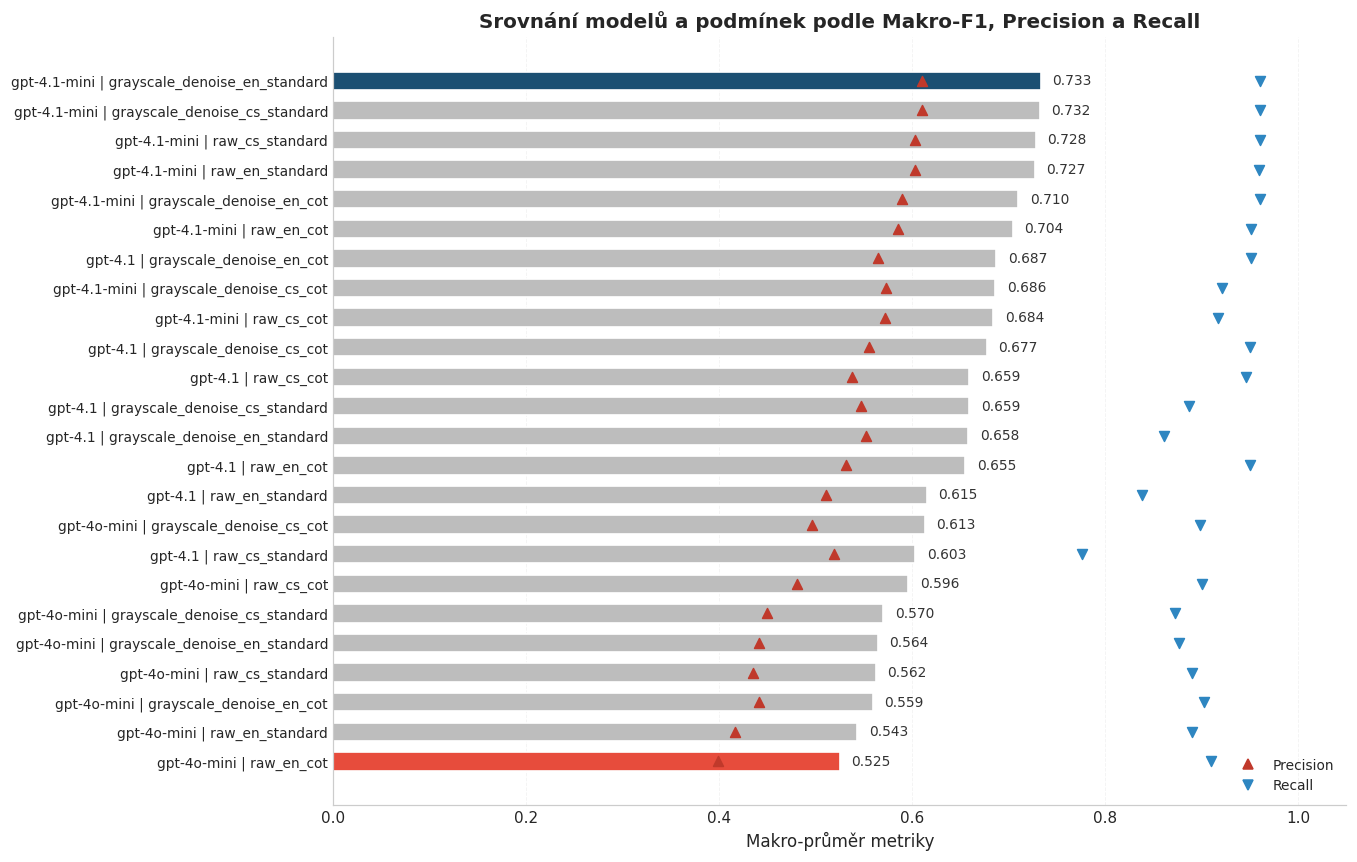

,Model,Podmínka,Makro-F1,Precision,Recall,Latence [ms],naklady_usd
0,gpt-4.1-mini,grayscale_denoise_en_standard,0.733,0.610,0.960,2801,0.088
1,gpt-4.1-mini,grayscale_denoise_cs_standard,0.732,0.610,0.960,3393,0.091
2,gpt-4.1-mini,raw_cs_standard,0.728,0.603,0.960,4868,0.091
3,gpt-4.1-mini,raw_en_standard,0.727,0.603,0.959,7872,0.088
4,gpt-4.1-mini,grayscale_denoise_en_cot,0.710,0.589,0.960,5380,0.110
5,gpt-4.1-mini,raw_en_cot,0.704,0.585,0.951,6948,0.110
6,gpt-4.1,grayscale_denoise_en_cot,0.687,0.564,0.951,3470,0.335
7,gpt-4.1-mini,grayscale_denoise_cs_cot,0.686,0.573,0.921,7070,0.113


In [3]:
serazene = souhrn.sort_values("Makro-F1", ascending=True).reset_index(drop=True)
barvy = [VITEZ if k == NEJLEPSI.konfigurace else
         PORAZENY if k == serazene.konfigurace.iloc[0] else NEUTRALNI
         for k in serazene.konfigurace]

fig, ax = plt.subplots(figsize=(12.5, 8))
ax.barh(serazene.konfigurace, serazene["Makro-F1"], color=barvy, height=0.62,
        edgecolor="white", linewidth=1.1)
for y, (f1, p, r) in enumerate(zip(serazene["Makro-F1"], serazene.Precision, serazene.Recall)):
    ax.text(f1 + 0.012, y, f"{f1:.3f}", va="center", fontsize=9, color="#333333")
    ax.scatter(p, y, marker="^", s=42, color="#C0392B", zorder=3)
    ax.scatter(r, y, marker="v", s=42, color="#2E86C1", zorder=3)

from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([], [], marker="^", linestyle="", color="#C0392B", label="Precision"),
                   Line2D([], [], marker="v", linestyle="", color="#2E86C1", label="Recall")],
          frameon=False, fontsize=9, loc="lower right")
ax.set_xlim(0, 1.05)
uprav_osu(ax, "Srovnání modelů a podmínek podle Makro-F1, Precision a Recall",
          x="Makro-průměr metriky")
ax.tick_params(axis="y", labelsize=9)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

display(tabulka(souhrn.sort_values("Makro-F1", ascending=False)
                      [["Model", "Podmínka", "Makro-F1", "Precision", "Recall",
                        "Latence [ms]", "naklady_usd"]]
                      .head(8).reset_index(drop=True)))

> **Zjištění.** Nejlepší je `gpt-4.1-mini` se **standardním promptem, bez řetězce
> úvah** — tři nejlepší konfigurace to potvrzují shodně (F1 0,733 / 0,732 / 0,728).
> Řetězec úvah naopak škodí, nejvíc poli `supplier`, kde F1 klesne z 0,60
> na 0,40–0,42. Rozdíl mezi surovým a mírně předzpracovaným skenem je oproti volbě
> modelu druhořadý.

## 6.2 Přesnost proti nákladům (Obrázek 4.11 v práci)

U textové větve platil kompromis: přesnější model byl dražší. Zde tomu tak není.

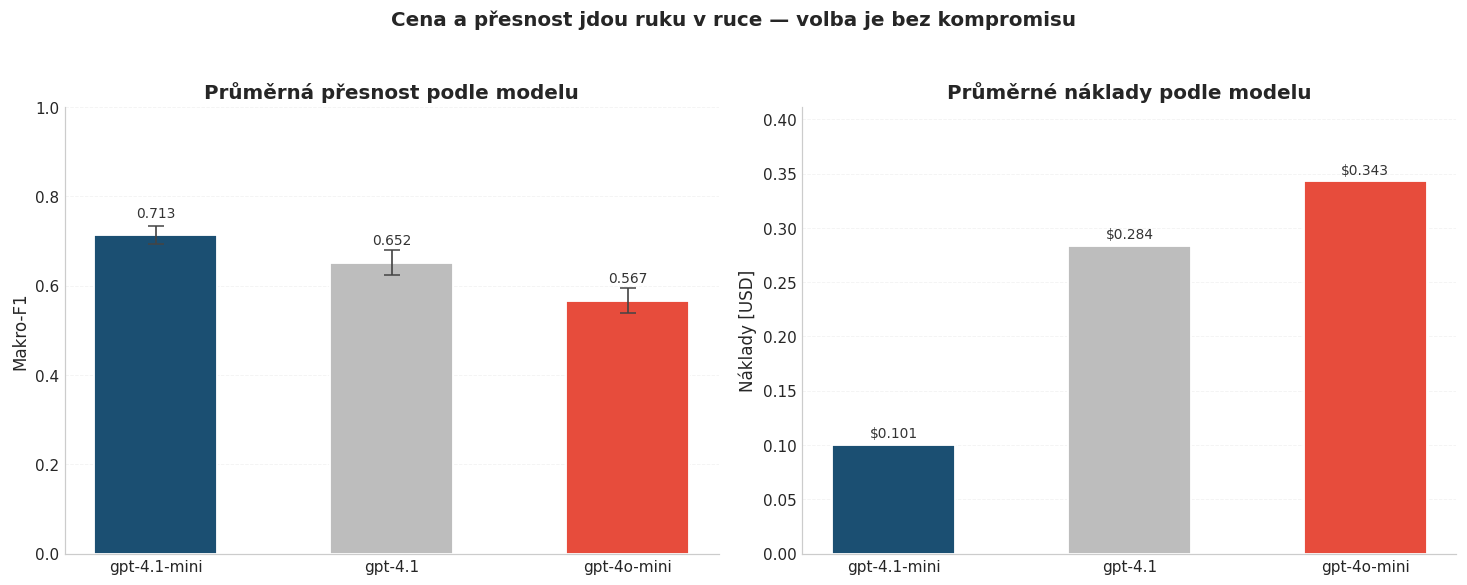

,makro_f1,odchylka,naklady
Model,,,
gpt-4.1-mini,0.713,0.020,0.100
gpt-4.1,0.652,0.029,0.284
gpt-4o-mini,0.566,0.028,0.343


In [4]:
dle_modelu = (souhrn.groupby("Model")
                    .agg(makro_f1=("Makro-F1", "mean"),
                         odchylka=("Makro-F1", "std"),
                         naklady=("naklady_usd", "mean"))
                    .sort_values("makro_f1", ascending=False))
NEJLEPSI_MODEL = dle_modelu.index[0]
barvy_modelu = barvy_vitez(list(dle_modelu.index), vitez=NEJLEPSI_MODEL,
                           porazeny=dle_modelu.index[-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2))

ax1.bar(dle_modelu.index, dle_modelu.makro_f1, yerr=dle_modelu.odchylka,
        color=barvy_modelu, width=0.52, edgecolor="white", linewidth=1.2,
        error_kw=dict(ecolor="#444444", lw=1.1, capsize=5))
popisky_sloupcu(ax1, fmt="{:.3f}", odsazeni=10)
ax1.set_ylim(0, 1.0)
uprav_osu(ax1, "Průměrná přesnost podle modelu", y="Makro-F1")
ax1.grid(axis="x", visible=False)

ax2.bar(dle_modelu.index, dle_modelu.naklady, color=barvy_modelu, width=0.52,
        edgecolor="white", linewidth=1.2)
popisky_sloupcu(ax2, fmt="${:.3f}")
ax2.set_ylim(0, dle_modelu.naklady.max() * 1.2)
uprav_osu(ax2, "Průměrné náklady podle modelu", y="Náklady [USD]")
ax2.grid(axis="x", visible=False)

fig.suptitle("Cena a přesnost jdou ruku v ruce — volba je bez kompromisu",
             fontsize=13, fontweight="semibold", y=1.02)
fig.tight_layout()
plt.show()

display(tabulka(dle_modelu.round(3)))

> **Zjištění.** `gpt-4.1-mini` je zároveň **nejpřesnější i nejlevnější**
> (Makro-F1 ≈ 0,715, ≈ 0,10 USD); `gpt-4.1` je uprostřed (≈ 0,65, ≈ 0,28 USD)
> a `gpt-4o-mini` nejhorší v obou ohledech (≈ 0,565, ≈ 0,34 USD). Volba je tedy
> jednoznačná, bez nutného kompromisu mezi cenou a kvalitou.

## 6.3 Kde multimodální model selhává

Průměr napříč poli zakrývá to podstatné — model je velmi nerovnoměrný.

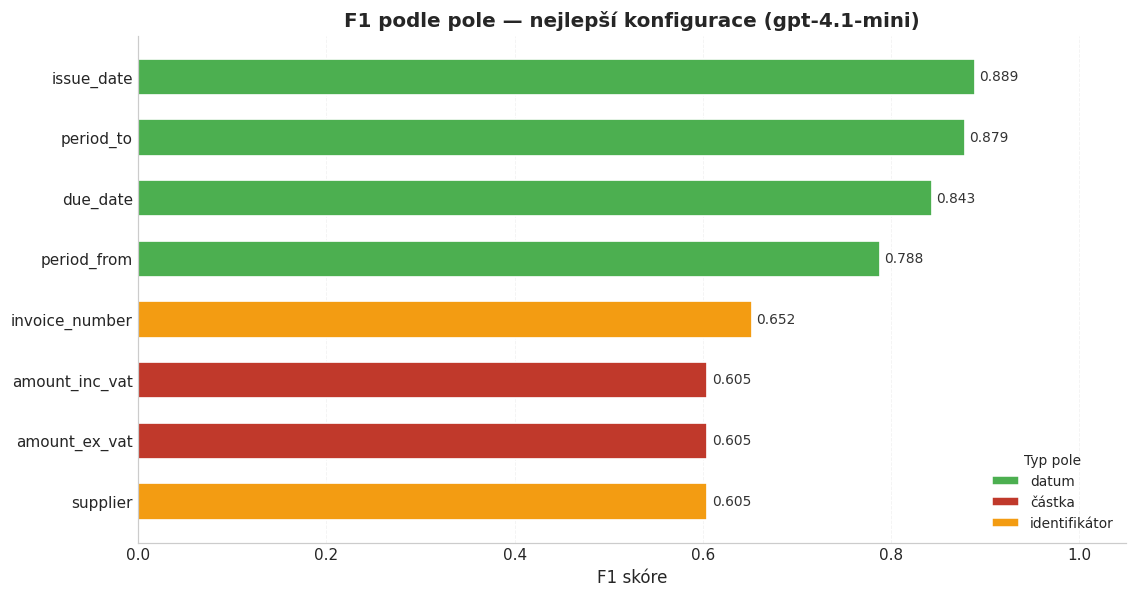

In [5]:
nejlepsi_pole = (pole[(pole.model == NEJLEPSI.Model) & (pole.condition == NEJLEPSI["Podmínka"])]
                     .sort_values("f1", ascending=True))

SKUPINY = {
    "amount_ex_vat": "částka", "amount_inc_vat": "částka",
    "due_date": "datum", "issue_date": "datum",
    "period_from": "datum", "period_to": "datum",
    "invoice_number": "identifikátor", "supplier": "identifikátor",
}
BARVY_SKUPIN = {"datum": "#4CAF50", "částka": "#C0392B", "identifikátor": "#F39C12"}

fig, ax = plt.subplots(figsize=(10.5, 5.6))
barvy = [BARVY_SKUPIN[SKUPINY[f]] for f in nejlepsi_pole.field]
ax.barh(nejlepsi_pole.field, nejlepsi_pole.f1, color=barvy, height=0.6,
        edgecolor="white", linewidth=1.1)
popisky_sloupcu(ax, fmt="{:.3f}", vodorovne=True)
ax.set_xlim(0, 1.05)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=b, label=s) for s, b in BARVY_SKUPIN.items()],
          frameon=False, fontsize=9, loc="lower right", title="Typ pole",
          title_fontsize=9)
uprav_osu(ax, f"F1 podle pole — nejlepší konfigurace ({NEJLEPSI.Model})", x="F1 skóre")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

> **Zjištění.** Pole s **datem** jsou stabilně silná (F1 0,72–0,89) — mají jasný
> vizuální vzor a model je najde spolehlivě. **Částky** jsou naopak nejslabším
> místem: model si pravidelně plete základ daně s celkovou částkou k úhradě.
> Právě kvůli tomu nemůže multimodální cesta nahradit sekvenční OCR přístup
> a zůstává **záložním řešením** pro dokumenty, kde OCR úplně selže.

## 6.4 Doménová adaptace metodou RAG pro pole `supplier`

U pole `supplier` dosahovala úspěšnost pouze 0,24–0,60, což pro praktické nasazení
nestačilo. Model název dodavatele četl správně, ale zapisoval jej pokaždé jinak
(„Centropol“ vs. „CENTROPOL ENERGY, a.s.“), takže se neshodoval s referenčním
záznamem.

Řešením je **RAG** (Retrieval-Augmented Generation): seznam všech dodavatelů
evidovaných v systému KEM je součástí promptu, model tedy vybírá název přímo
z tohoto seznamu. Pokud se přesto vrátí mírně odlišný zápis, výstup se dodatečně
porovná se stejným seznamem a nahradí nejbližší shodou.

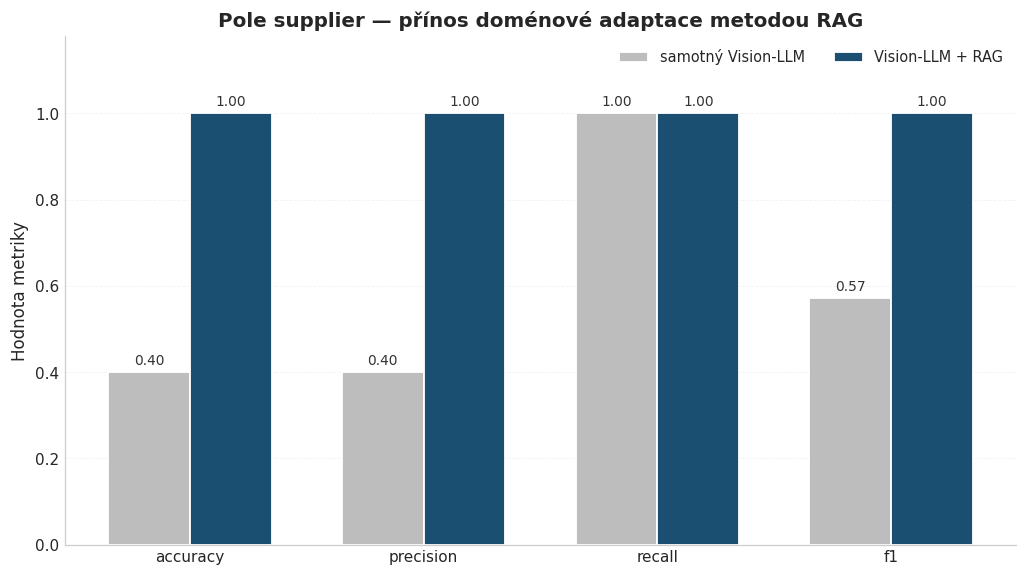

Vyhodnoceno na 60 dokumentech proti 6 kanonickým záznamům dodavatelů.


,before,after,delta
metric,,,
accuracy,0.4000,1.0000,0.6000
precision,0.4000,1.0000,0.6000
recall,1.0000,1.0000,0.0000
f1,0.5714,1.0000,0.4286


In [6]:
rag = pd.read_csv(DATA / "06_multimodalni" / "rag_supplier_before_after.csv")
metriky = rag[rag.metric.isin(["accuracy", "precision", "recall", "f1"])].copy()
metriky[["before", "after"]] = metriky[["before", "after"]].astype(float)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
x, sirka = np.arange(len(metriky)), 0.35
ax.bar(x - sirka / 2, metriky.before, sirka, label="samotný Vision-LLM",
       color=NEUTRALNI, edgecolor="white", linewidth=1.2)
ax.bar(x + sirka / 2, metriky.after, sirka, label="Vision-LLM + RAG",
       color=VITEZ, edgecolor="white", linewidth=1.2)
popisky_sloupcu(ax, fmt="{:.2f}")
ax.set_xticks(x)
ax.set_xticklabels(metriky.metric)
ax.set_ylim(0, 1.18)
uprav_osu(ax, "Pole supplier — přínos doménové adaptace metodou RAG", y="Hodnota metriky")
ax.legend(frameon=False, fontsize=9.5, ncol=2)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

pocet = rag.loc[rag.metric == "n_docs", "before"].iloc[0]
zaznamy = rag.loc[rag.metric == "n_canonical_refs", "before"].iloc[0]
print(f"Vyhodnoceno na {pocet} dokumentech proti {zaznamy} kanonickým záznamům dodavatelů.")
display(tabulka(metriky.set_index("metric")[["before", "after", "delta"]], desetinna=4))

> **Zjištění.** Přesnost pole `supplier` vzrostla z **0,40 na 1,00**. Jde
> o nejlevnější a nejúčinnější zásah v celé práci — bez dotrénování modelu, pouze
> doplněním znalostní báze do promptu a deterministickým dohledáním nejbližší shody.

## Závěr

**Zvolená konfigurace záložní větve: `gpt-4.1-mini`, zero-shot prompt, mírné
předzpracování a RAG pro pole dodavatele.**

| Silné stránky | Slabiny |
|---|---|
| Nejpřesnější i nejlevnější zároveň | Částky — model plete základ daně s celkovou částkou |
| Data s jasným vizuálním vzorem (F1 0,72–0,89) | Bez RAG selhává na názvu dodavatele |
| Nepotřebuje OCR, odpadá kumulace chyb | Průměrné F1 nedosahuje na textovou větev |

Vision-LLM tedy spolehlivě čte údaje s jasným vizuálním vzorem i dodavatele,
u částek ale přesnost nestačí, a proto **sám o sobě nemůže nahradit OCR přístup**.

### Návrh finálního řešení — kaskádová architektura

Žádná z obou strategií nefunguje nejlépe za všech okolností. Řešením je jejich
spojení do jedné pipeline, která mezi nimi podle potřeby přepíná:

1. Dokument vstoupí do systému a projde **hlavní cestou** (notebooky `02`–`05`):
   předzpracování → Tesseract → JSON-light → GPT‑4.1 s few-shot promptem.
2. Výstup projde normalizací, validací a **akceptační kontrolou** — ověří se, že
   jde o čitelný JSON, že obsahuje klíčová pole a že si je model dostatečně jistý.
3. Pokud kontrola projde, systém vrátí výsledek.
4. Pokud ne, dokument postoupí na **záložní cestu** (tento notebook): stejně
   předzpracovaný sken se předá modelu `gpt-4.1-mini` se zero-shot promptem
   doplněným o RAG seznam dodavatelů.
5. Výstup znovu projde validací. Pokud vyhoví, systém jej vrátí; pokud ne, vrátí
   se i tak nejlepší dostupný výsledek — další iterace už k dispozici není.

Vyhodnocení této architektury na nezávislé sadě DS1 obsahuje notebook `07`.